
# **Introduction to DBSCAN**
DBSCAN, an acronym for Density-Based Spatial Clustering of Applications with Noise, is a powerful clustering algorithm designed to discover clusters of arbitrary shapes in spatial databases with noise. Unlike distance-based methods such as K-Means, DBSCAN leverages the concept of density to group data points.

<br><br>

## **A Brief History**
The foundational ideas for density-based clustering trace back to Robert F. Ling's work in 1972 on k-clusters, which had a computational complexity of O(N^3). The modern version of DBSCAN, with a significantly improved runtime complexity of O(N^2), was proposed by a group of researchers in 1996. Its innovation was recognized with the 'Test of Time Award' at a leading data mining conference in 2014.

<br><br>



## **DBSCAN VS KMeans**


Let's briefly explore visually the differences between DBSCAN and other clustering techniques, such as K-Means Clustering.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### **Blobs Dataset**

This dataset consists of several isotropic Gaussian blobs. It's often used to demonstrate algorithms that perform well on convex, well-separated clusters, like K-Means.

In [3]:
from sklearn.datasets import make_blobs

# Generate isotropic Gaussian blobs for clustering
X_blobs, y_blobs = make_blobs(n_samples=500, centers=4, cluster_std=0.60, random_state=0)

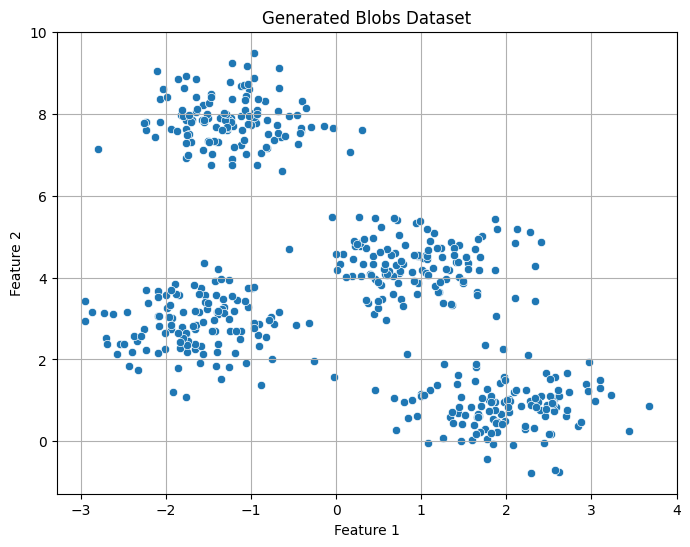

In [4]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_blobs[:, 0], y=X_blobs[:, 1])
plt.title('Generated Blobs Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)
plt.show()

#### **Moons Dataset**

The moons dataset is a classic example for evaluating clustering algorithms on non-convex shapes. Algorithms like K-Means often struggle here, while density-based methods like DBSCAN can perform better.

In [5]:
from sklearn.datasets import make_moons, make_circles

# Generate two interleaving half-moon shapes
X_moons, y_moons = make_moons(n_samples=500, noise=0.05, random_state=0)

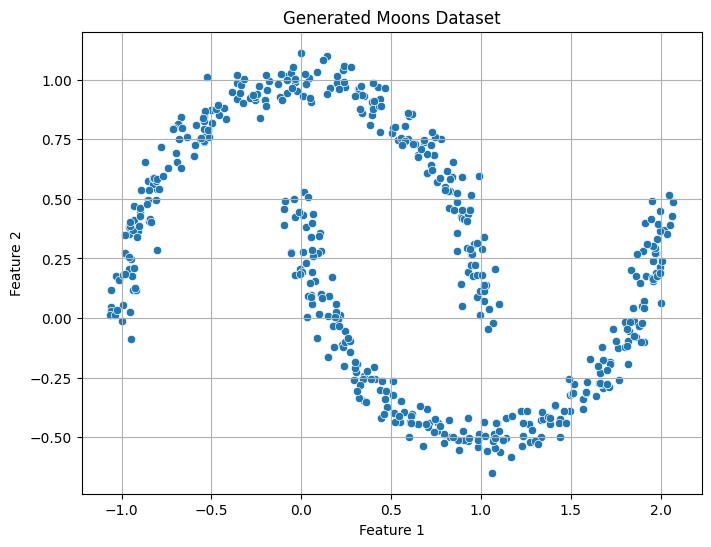

In [6]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_moons[:, 0], y=X_moons[:, 1])
plt.title('Generated Moons Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)
plt.show()

#### **Circles Dataset**

Similar to the moons dataset, the circles dataset presents a challenge for algorithms that assume spherical or convex clusters. It highlights the need for algorithms capable of identifying clusters with complex boundaries.

In [8]:
from sklearn.datasets import make_circles

# Generate concentric circles
X_circles, y_circles = make_circles(n_samples=500, factor=0.5, noise=0.05, random_state=0)

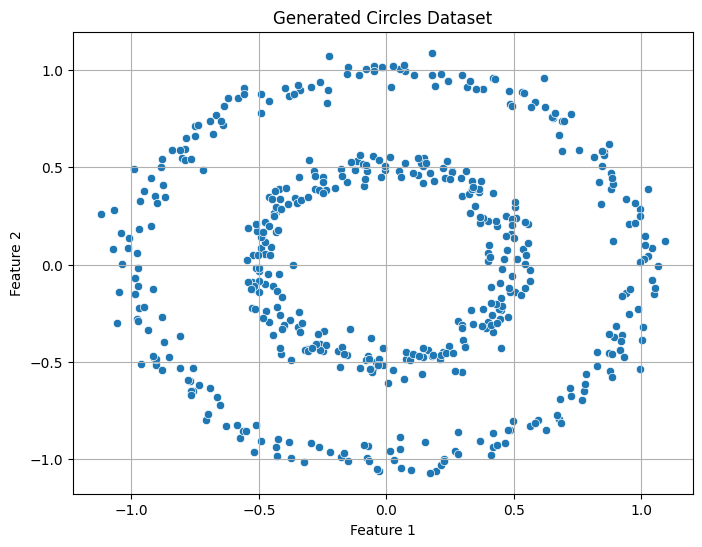

In [9]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_circles[:, 0], y=X_circles[:, 1])
plt.title('Generated Circles Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)
plt.show()

## **Kmeans Results**

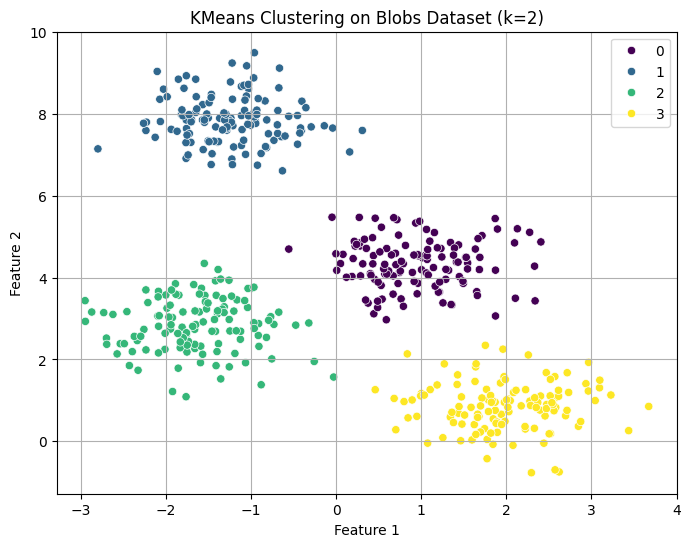

In [ ]:
from sklearn.cluster import KMeans
model = KMeans(n_clusters = 4)

# Apply KMeans to the Blobs dataset
kmeans_blobs = model.fit_predict(X_blobs)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_blobs[:, 0], y=X_blobs[:, 1], hue=kmeans_blobs, palette='viridis', legend='full')
plt.title('KMeans Clustering on Blobs Dataset (k=2)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)
plt.show()

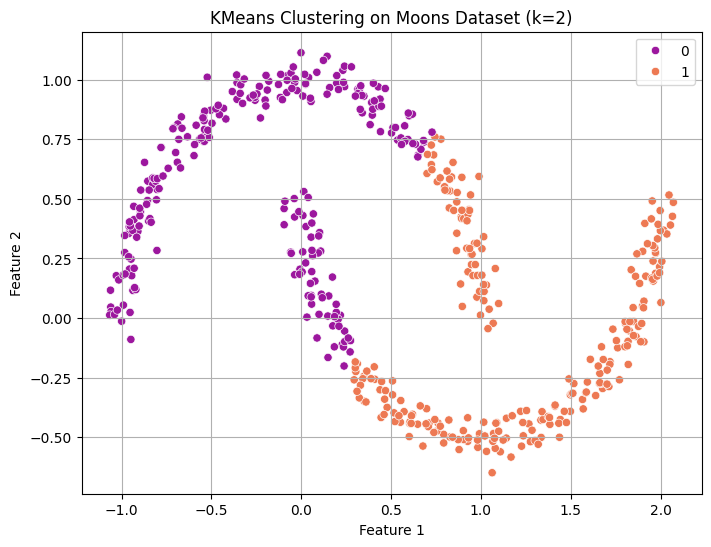

In [ ]:
from sklearn.cluster import KMeans
model = KMeans(n_clusters = 2)

# Apply KMeans to the Moons dataset
kmeans_moons = model.fit_predict(X_moons)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_moons[:, 0], y=X_moons[:, 1], hue=kmeans_moons, palette='plasma', legend='full')
plt.title('KMeans Clustering on Moons Dataset (k=2)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)
plt.show()

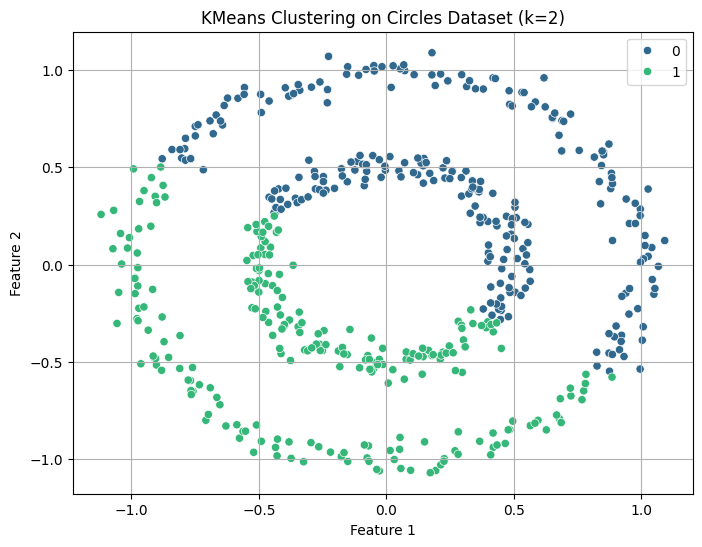

In [ ]:
from sklearn.cluster import KMeans
model = KMeans(n_clusters = 2)

# Apply KMeans to the Circles dataset
kmeans_circles = model.fit_predict(X_circles)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_circles[:, 0], y=X_circles[:, 1], hue=kmeans_circles, palette='viridis', legend='full')
plt.title('KMeans Clustering on Circles Dataset (k=2)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)
plt.show()

## **DBSCAN Results**

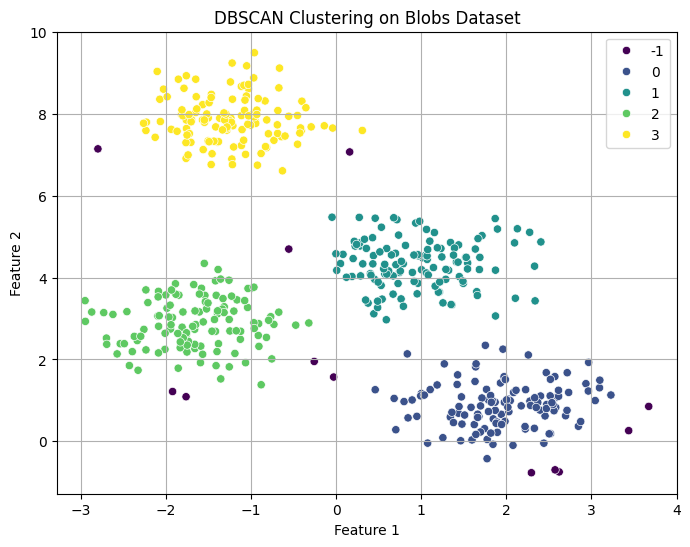

In [ ]:
from sklearn.cluster import DBSCAN

# DBSCAN on Blobs Dataset
dbsc_blobs = DBSCAN(eps=0.5, min_samples=5).fit_predict(X_blobs)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_blobs[:, 0], y=X_blobs[:, 1], hue=dbsc_blobs, palette='viridis', legend='full')
plt.title('DBSCAN Clustering on Blobs Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)
plt.show()

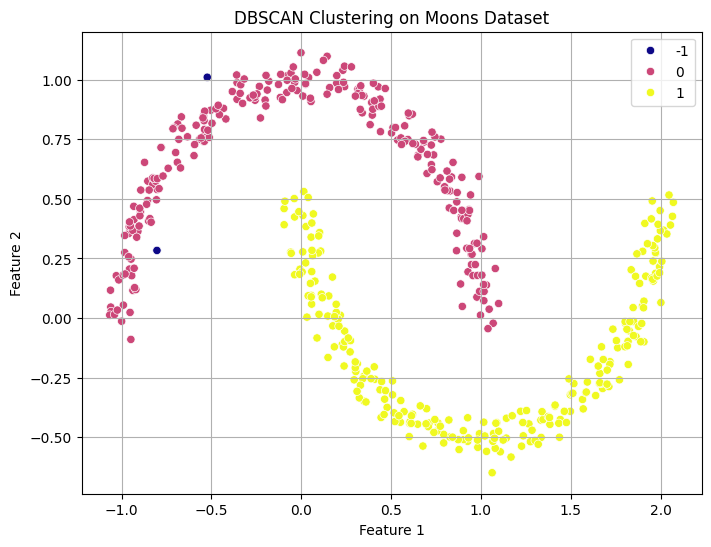

In [ ]:
# DBSCAN on Moons Dataset (adjusting parameters for better fit)
dbsc_moons = DBSCAN(eps=0.1, min_samples=5).fit_predict(X_moons)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_moons[:, 0], y=X_moons[:, 1], hue=dbsc_moons, palette='plasma', legend='full')
plt.title('DBSCAN Clustering on Moons Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)
plt.show()

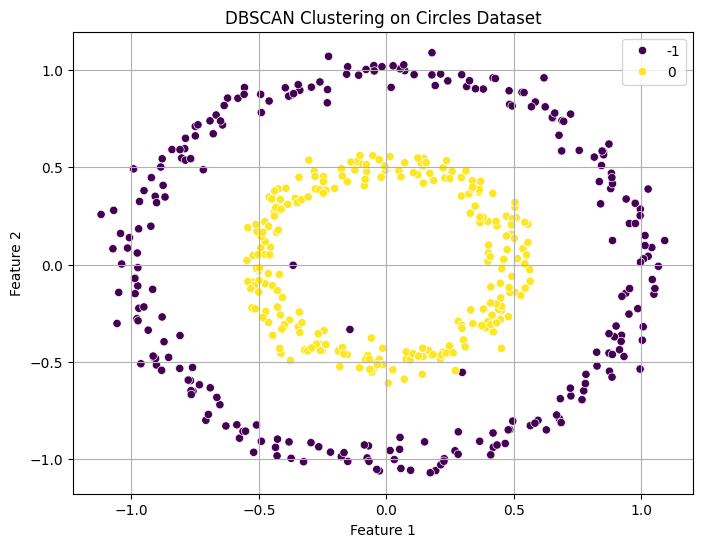

In [ ]:
# DBSCAN on Circles Dataset (adjusting parameters for better fit)
dbsc_circles = DBSCAN(eps=0.1, min_samples=11).fit_predict(X_circles)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_circles[:, 0], y=X_circles[:, 1], hue=dbsc_circles, palette='viridis', legend='full')
plt.title('DBSCAN Clustering on Circles Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)
plt.show()

<br>


## **Core Principles of DBSCAN**
DBSCAN's primary focus is on the density of points for assigning cluster labels. This approach allows it to identify cluster segmentations that are challenging for other algorithms, particularly those with non-convex shapes.

Consider datasets like the 'moons' or 'circles' where traditional distance-based methods (e.g., K-Means) often fail to capture the natural groupings. K-Means, by design, seeks to form spherical clusters, leading to suboptimal results on such datasets. DBSCAN, however, can accurately identify these complex shapes by focusing on regions of high-density separated by regions of lower density.

<br><br>

### **Key Hyperparameters**
DBSCAN operates using two crucial hyperparameters:

1.  **Epsilon (`eps`):** This parameter defines the maximum distance between two samples for one to be considered as being in the neighborhood of the other. It determines the radius of the neighborhood to be considered around each point.
2.  **Minimum Samples (`min_samples`):** This parameter specifies the minimum number of samples (or total weight) required in an `eps`-neighborhood for a point to be considered a **core point**.

These hyperparameters must be set prior to running the DBSCAN algorithm, and their careful selection is critical for effective clustering.

<br><br>

### **Point Types in DBSCAN**
DBSCAN categorizes each data point into one of three types, which are fundamental to its operation:

1.  **Core Point:** A point is designated as a core point if its `eps`-neighborhood contains at least `min_samples` (including the point itself). Core points are central to the high-density regions that form clusters.
2.  **Border Point:** A point is classified as a border point if it has fewer than `min_samples` within its `eps`-neighborhood but falls within the `eps`-neighborhood of a core point. Border points lie on the edge of a cluster.
3.  **Noise Point (Outlier):** A point that is neither a core point nor a border point is considered a noise point or an outlier. These points are in low-density regions and are not part of any cluster.

<br>




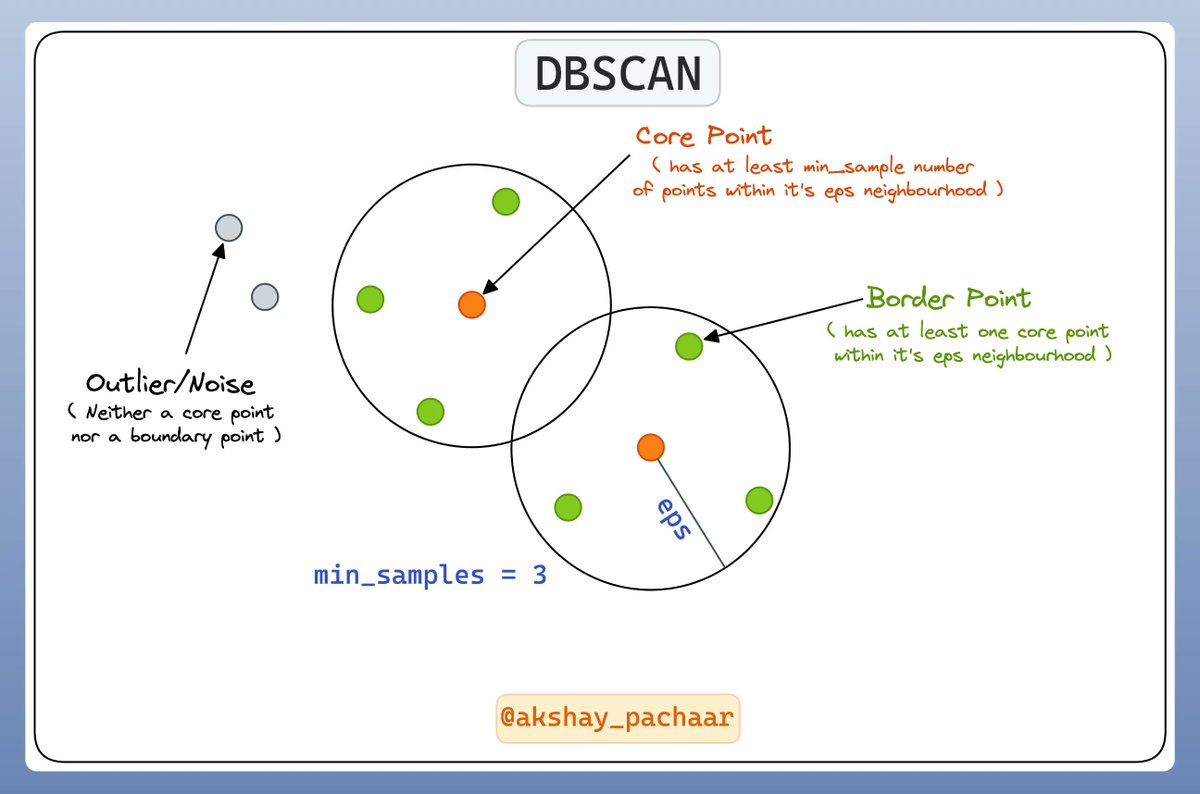

<br>



### **The DBSCAN Procedure**
The algorithm follows a straightforward iterative process:

1.  **Point Selection:** Begin by selecting an arbitrary data point that has not yet been assigned to a cluster or classified by type.
2.  **Type Determination:** Determine the type of the selected point (core, border, or noise) based on its `eps`-neighborhood and `min_samples` criterion.
3.  **Cluster Expansion (if Core Point):** If the selected point is a core point, a new cluster is initiated. All points directly density-reachable from this core point (i.e., other core points and border points within its `eps`-neighborhood) are added to the same cluster. This process recursively expands to include all density-reachable points.
4.  **Iteration:** Steps 1-3 are repeated until all points in the dataset have been visited and assigned a cluster label or marked as noise.

It is important to note that while core and border points belong to the same cluster, they serve different roles in defining the cluster's structure and boundaries. Noise points are automatically identified and excluded from clusters, a distinct advantage of DBSCAN.


<br>


### **Visualizer:**

- [Clustering Visualizer](https://clustering-visualizer.web.app/dbscan)
- [Visualizing DBSCAN Clustering](https://www.naftaliharris.com/blog/visualizing-dbscan-clustering/)
- [DBSCAN Clustering Visualization](https://www.philippe-fournier-viger.com/tools/dbscan_clusters_demo.php)


<br><br>

## **DBSCAN Hyperparameters**


Let's explore the hyperparameters for DBSCAN and how they can change results!

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
two_blobs = pd.read_csv('/content/cluster_two_blobs.csv')
two_blobs_outliers = pd.read_csv('/content/cluster_two_blobs_outliers.csv')

<Axes: xlabel='X1', ylabel='X2'>

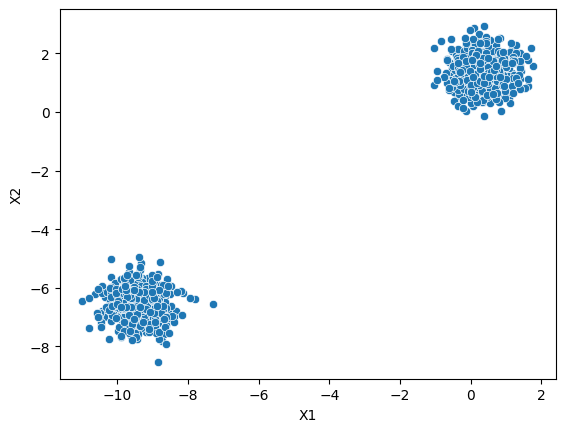

In [13]:
sns.scatterplot(data=two_blobs,x='X1',y='X2')

<Axes: xlabel='X1', ylabel='X2'>

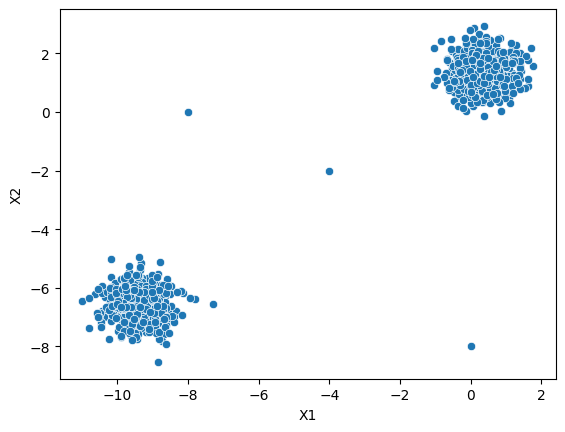

In [14]:
# plt.figure(figsize=(10,6),dpi=200)
sns.scatterplot(data=two_blobs_outliers,x='X1',y='X2')

In [15]:
def display_categories(model,data):
    labels = model.fit_predict(data)
    sns.scatterplot(data=data,x='X1',y='X2',hue=labels,palette='Set1')

In [16]:
from sklearn.cluster import DBSCAN

In [ ]:
help(DBSCAN)

Help on class DBSCAN in module sklearn.cluster._dbscan:

class DBSCAN(sklearn.base.ClusterMixin, sklearn.base.BaseEstimator)
 |  DBSCAN(eps=0.5, *, min_samples=5, metric='euclidean', metric_params=None, algorithm='auto', leaf_size=30, p=None, n_jobs=None)
 |
 |  Perform DBSCAN clustering from vector array or distance matrix.
 |
 |  DBSCAN - Density-Based Spatial Clustering of Applications with Noise.
 |  Finds core samples of high density and expands clusters from them.
 |  Good for data which contains clusters of similar density.
 |
 |  This implementation has a worst case memory complexity of :math:`O({n}^2)`,
 |  which can occur when the `eps` param is large and `min_samples` is low,
 |  while the original DBSCAN only uses linear memory.
 |  For further details, see the Notes below.
 |
 |  Read more in the :ref:`User Guide <dbscan>`.
 |
 |  Parameters
 |  ----------
 |  eps : float, default=0.5
 |      The maximum distance between two samples for one to be considered
 |      as in t

In [17]:
dbscan = DBSCAN()

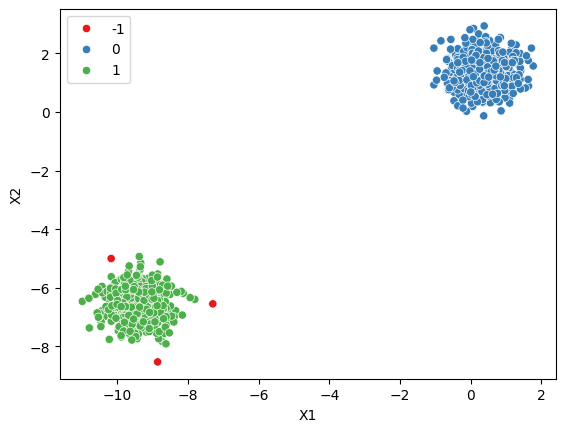

In [18]:
display_categories(dbscan,two_blobs)

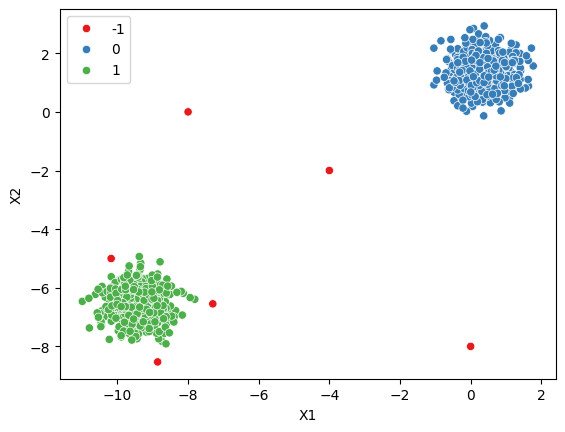

In [19]:
display_categories(dbscan,two_blobs_outliers)

<br>

### **Epsilon**

    eps : float, default=0.5
     |      The maximum distance between two samples for one to be considered
     |      as in the neighborhood of the other. This is not a maximum bound
     |      on the distances of points within a cluster. This is the most
     |      important DBSCAN parameter to choose appropriately for your data set
     |      and distance function.

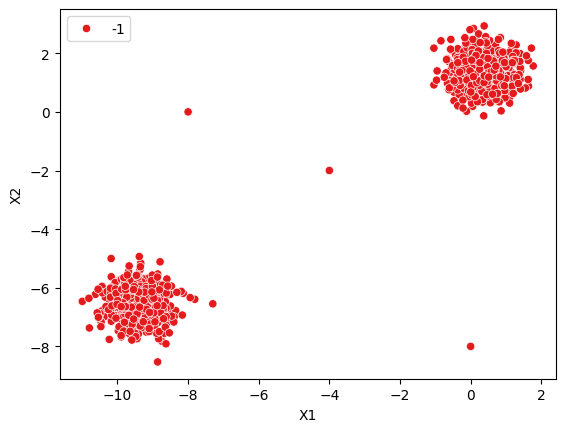

In [20]:
# Tiny Epsilon --> Tiny Max Distance --> Everything is an outlier (class=-1)
dbscan = DBSCAN(eps=0.001)
display_categories(dbscan,two_blobs_outliers)

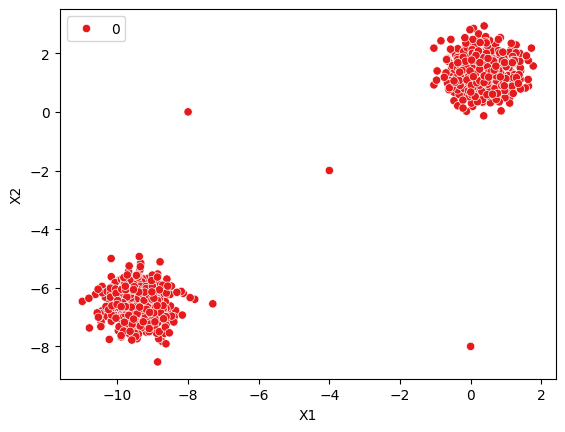

In [21]:
# Huge Epsilon --> Huge Max Distance --> Everything is in the same cluster (class=0)
dbscan = DBSCAN(eps=10)
display_categories(dbscan,two_blobs_outliers)

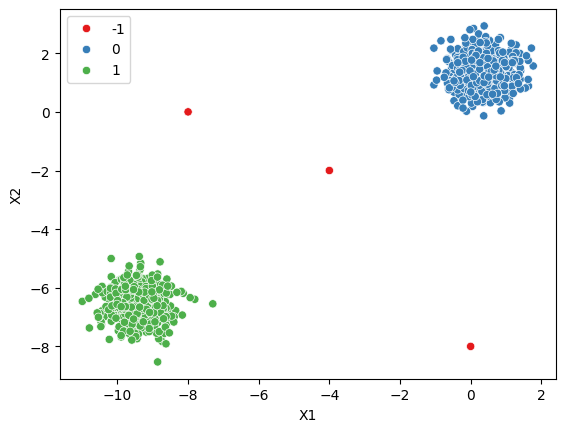

In [22]:
# How to find a good epsilon?
#plt.figure(figsize=(10,6),dpi=200)
dbscan = DBSCAN(eps=1)
display_categories(dbscan,two_blobs_outliers)

In [23]:
dbscan.labels_

array([ 0,  1,  0, ..., -1, -1, -1])

In [24]:
dbscan.labels_ == -1

array([False, False, False, ...,  True,  True,  True])

In [25]:
# Total num of outliers

np.sum(dbscan.labels_ == -1)

np.int64(3)

In [26]:
# Percent of points classified as outliers

100 * np.sum(dbscan.labels_ == -1) / len(dbscan.labels_)

np.float64(0.29910269192422734)

### **Charting reasonable Epsilon values**

In [27]:
outlier_percent = []
number_of_outliers = []

for eps in np.linspace(0.001,10,100):

    # Create Model
    dbscan = DBSCAN(eps=eps)
    dbscan.fit(two_blobs_outliers)

    # Log Number of Outliers
    number_of_outliers.append(np.sum(dbscan.labels_ == -1))

    # Log percentage of points that are outliers
    perc_outliers = 100 * np.sum(dbscan.labels_ == -1) / len(dbscan.labels_)

    outlier_percent.append(perc_outliers)

Text(0.5, 0, 'Epsilon Value')

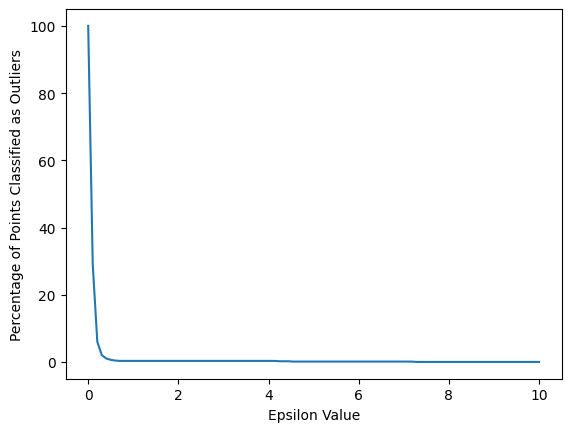

In [28]:
sns.lineplot(x=np.linspace(0.001,10,100),y=outlier_percent)
plt.ylabel("Percentage of Points Classified as Outliers")
plt.xlabel("Epsilon Value")

Above plots goes from everything being outlier to nothing being outlier. So we zoom in:

(0.0, 1.0)

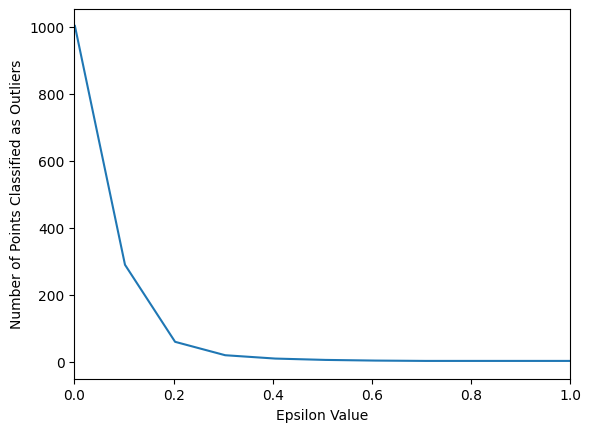

In [29]:
sns.lineplot(x=np.linspace(0.001,10,100),y=number_of_outliers)
plt.ylabel("Number of Points Classified as Outliers")
plt.xlabel("Epsilon Value")
plt.xlim(0,1)

### **Do we want to think in terms of percentage targeting instead?**

If so, you could "target" a percentage, like choose a range producing 1%-5% as outliers.

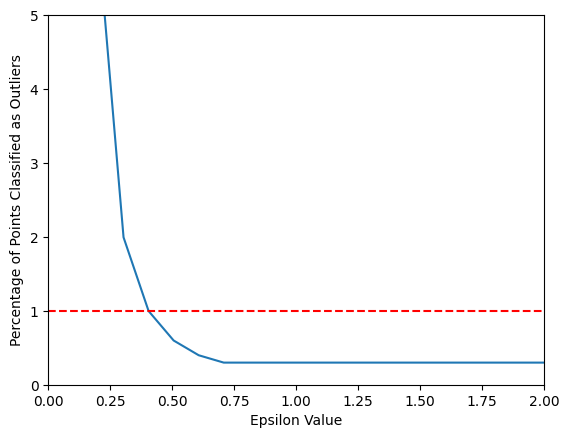

In [30]:
sns.lineplot(x=np.linspace(0.001,10,100),y=outlier_percent)
plt.ylabel("Percentage of Points Classified as Outliers")
plt.xlabel("Epsilon Value")
plt.ylim(0,5)
plt.xlim(0,2)
plt.hlines(y=1,xmin=0,xmax=2,colors='red',ls='--')

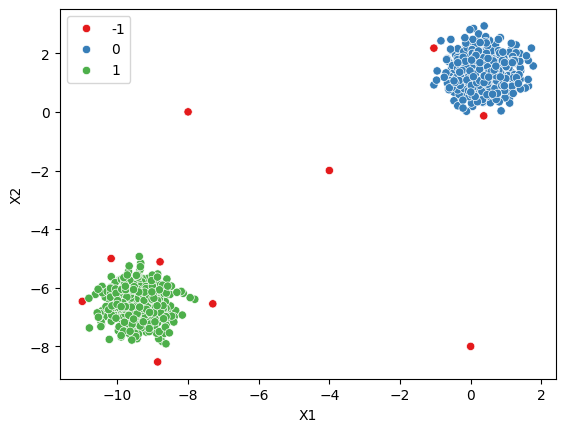

In [31]:
# How to find a good epsilon?
dbscan = DBSCAN(eps=0.4)
display_categories(dbscan,two_blobs_outliers)

### **Do we want to think in terms of number of outliers targeting instead?**

If so, you could "target" a number of outliers, such as 3 points as outliers.

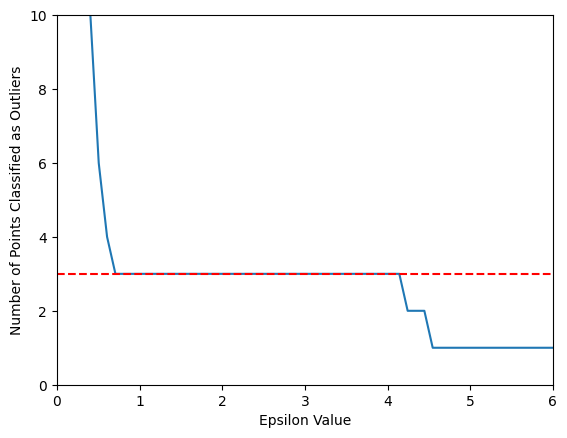

In [34]:
sns.lineplot(x=np.linspace(0.001,10,100),y=number_of_outliers)
plt.ylabel("Number of Points Classified as Outliers")
plt.xlabel("Epsilon Value")
plt.ylim(0,10)
plt.xlim(0,6)
plt.hlines(y=3,xmin=0,xmax=10,colors='red',ls='--')

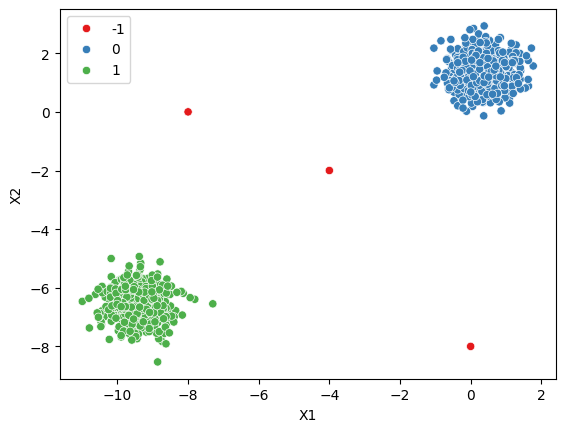

In [35]:
# How to find a good epsilon?
dbscan = DBSCAN(eps=0.75)
display_categories(dbscan,two_blobs_outliers)

### **Minimum Samples**

     |  min_samples : int, default=5
     |      The number of samples (or total weight) in a neighborhood for a point
     |      to be considered as a core point. This includes the point itself.
     

How to choose minimum number of points?

https://stats.stackexchange.com/questions/88872/a-routine-to-choose-eps-and-minpts-for-dbscan

In [36]:
outlier_percent = []

for n in np.arange(1,100): # 100 means almost 10% of the points are classified as minimum number of points,
                            # the higher minimum number of points, the higher outliers

    # Create Model
    dbscan = DBSCAN(min_samples=n)
    dbscan.fit(two_blobs_outliers)

    # Log percentage of points that are outliers
    perc_outliers = 100 * np.sum(dbscan.labels_ == -1) / len(dbscan.labels_)

    outlier_percent.append(perc_outliers)


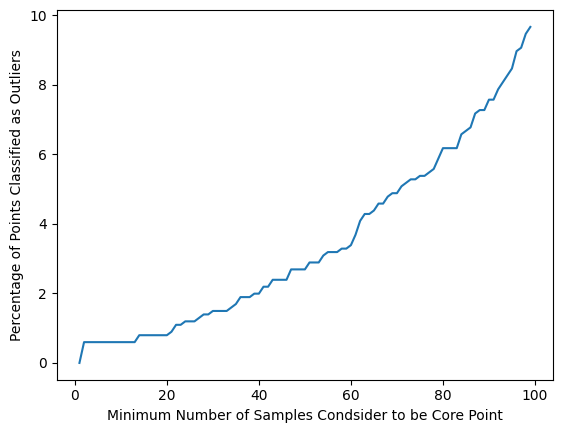

In [38]:
sns.lineplot(x=np.arange(1,100),y=outlier_percent)
plt.ylabel("Percentage of Points Classified as Outliers")
plt.xlabel("Minimum Number of Samples");

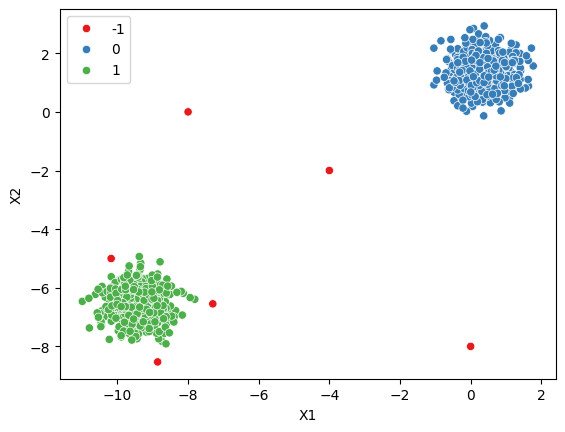

In [ ]:
num_dim = two_blobs_outliers.shape[1]

dbscan = DBSCAN(min_samples=2*num_dim)
display_categories(dbscan,two_blobs_outliers)

Suggestion about start point of `min_samples`: 2 * dim of your data

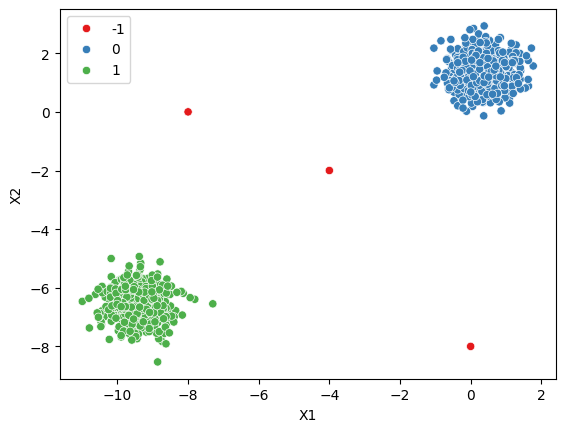

In [ ]:
num_dim = two_blobs_outliers.shape[1] # = 2 (x1 & x2)

dbscan = DBSCAN(eps=0.75,min_samples=2*num_dim)
display_categories(dbscan,two_blobs_outliers)

If `min_samples = 1` those 3 points are not outliers anymore, each is a cluster.

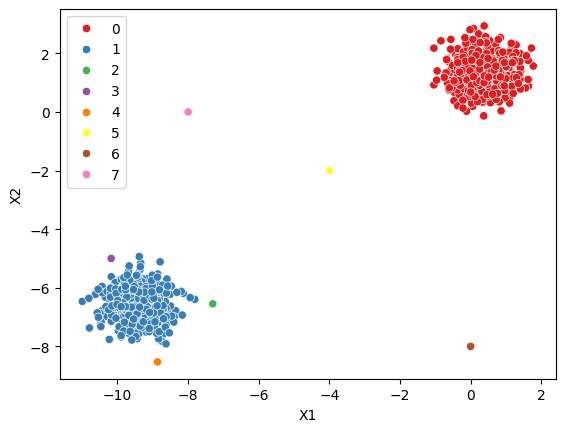

In [ ]:
dbscan = DBSCAN(min_samples=1)
display_categories(dbscan,two_blobs_outliers)

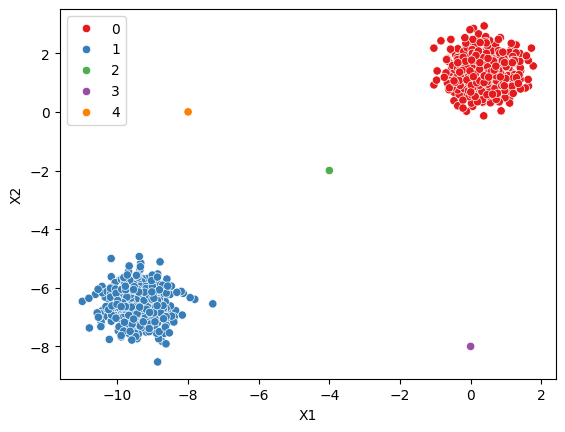

In [ ]:
dbscan = DBSCAN(eps=0.75,min_samples=1)
display_categories(dbscan,two_blobs_outliers)


<br>


### **Advantages of DBSCAN**
*   **Arbitrary Shape Discovery:** Capable of finding clusters of any shape, not just convex or spherical ones.
*   **Noise Detection:** Automatically identifies and separates outliers (noise points).
*   **No Pre-defined Number of Clusters:** Does not require the user to specify the number of clusters in advance.

<br>


### **Considerations**
*   **Parameter Sensitivity:** Performance can be highly sensitive to the choice of `eps` and `min_samples`.
*   **Varying Densities:** May struggle with datasets containing clusters of significantly varying densities, as a single set of `eps` and `min_samples` might not be optimal for all clusters.

Understanding these concepts is foundational for effectively applying and interpreting DBSCAN in practical data analysis scenarios.
